In [1]:
# Import Packages
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import ast
from wordcloud import WordCloud
from text import plot_histogram, plot_word_cloud
import pickle
import math

In [2]:
# Load variables
df = pd.read_csv("../data/document_data_clean_filtered.csv")
df_gallica_docs = pd.read_csv("../data/other/gallica_year_distrib.csv")

with open("saved_variables/topic_model.pkl", "rb") as fp:
    topic_model = pickle.load(fp)

with open("saved_variables/less_outliers.pkl", "rb") as fp:
    less_outliers_topics = pickle.load(fp)

with open("saved_variables/extracted_docs_list.pkl", "rb") as fp:
    docs_text, docs_ark = pickle.load(fp)

c:\Users\ASUS\Programmation\lhst-the-ecology-of-eucalyptus\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Change variables names to english
metatopics = {
    "Géographie": "Geography",
    "Eucalyptus / Propriétés Botaniques": "Eucalyptus and Botanical Properties",
    "Faune et Flore": "Fauna and Flora",
    "Malaria / Assainissement": "Malaria and Drainage",
    "Maladies": "Diseases",       
    "Médecine/Médicaments": "Medicine and Medication",
    "Propriétés Chimiques": "Chimical Properties",
    "Industrie / Production": "Industry and Manufacturing",
    "Institutions / Transport": "Institutions and Transport",
    "Description": "Descriptions",
    "Autres": "Others",
    "Erreurs": "Errors"
}

type_publication = {
    "monographie": "monograph",
    "presse généraliste": "generalist press",
    "presse spécialisée": "specialized press",
    "presse officielle": "official press",
    "annuaire": "directory"
}

place_of_publication = {
    "Paris / Île de France": "Paris",
    "France Métropolitaine": "Metropolitan France",
    "Sud de la France": "South France",
    "Afrique du Nord": "North Africa",
    "Madagascar": "Madagascar",
    "Europe": "Europe",
    "Autres": "Others"
}

df = df.rename(columns={"type_clean": "publication_type", "publisher_place_country": "publisher_country"})

df['topics'] = df['topics'].apply(lambda x: ast.literal_eval(x))
df['metatopics'] = df['metatopics'].apply(lambda x: ast.literal_eval(x))
df['metatopics'] = df['metatopics'].apply(lambda x: [metatopics[metatopic] for metatopic in x])
df['publication_type'] = df['publication_type'].apply(lambda x: type_publication[x])
df['publisher_country'] = df['publisher_country'].apply(lambda x: place_of_publication[x])

df_topics_exploded = df.explode("topics")
df_metatopics_exploded = df.explode("metatopics")

In [4]:
# Set palettes
palette_types = {
    'directory': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
    'generalist press': 'tab:orange',
    'specialized press': 'tab:green',
    'official press': 'tab:red',
    'monograph': 'tab:blue',
}

# 2) Methodology

## 2.2) Topic Modeling

In [16]:
num_err_context = len(df_metatopics_exploded[df_metatopics_exploded["metatopics"] == "Errors"]) / len (df_metatopics_exploded)
print(f'Number of "Error" contexts: {round(num_err_context * 100, 2) }%')

Number of "Error" contexts: 7.01%


# 3) Results

## 3.1) General Overview

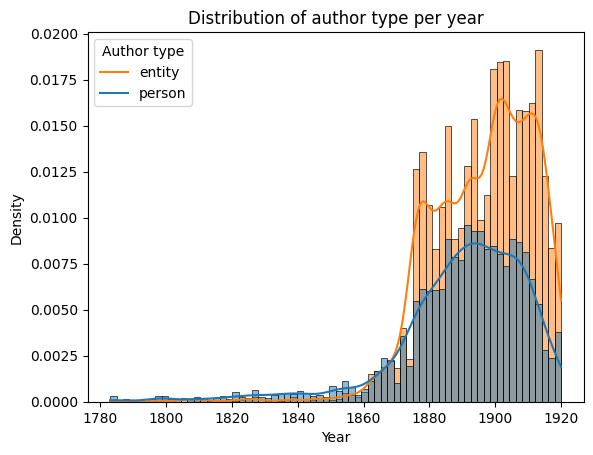

In [5]:
sns.histplot(df, x="date_clean", bins=70, hue="author_type_clean", kde=True, stat="density", label="Eucalyptus", alpha=0.5)
plt.title("Distribution of author type per year")
plt.xlabel("Year")
plt.legend(title='Author type', loc='upper left', labels=['entity', 'person'])
plt.show()

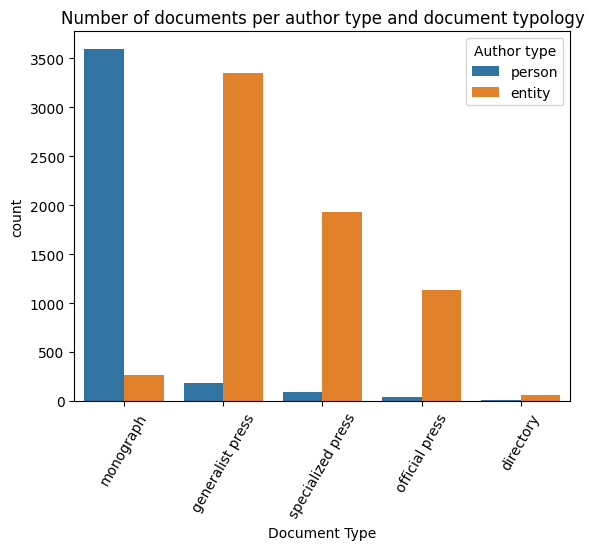

In [6]:
sns.countplot(data=df, x="publication_type", hue="author_type_clean")
plt.xticks(rotation=60)
plt.title("Number of documents per author type and document typology")
plt.xlabel("Document Type")
plt.legend(title='Author type', loc='upper right', labels=['person', 'entity'])
plt.show()

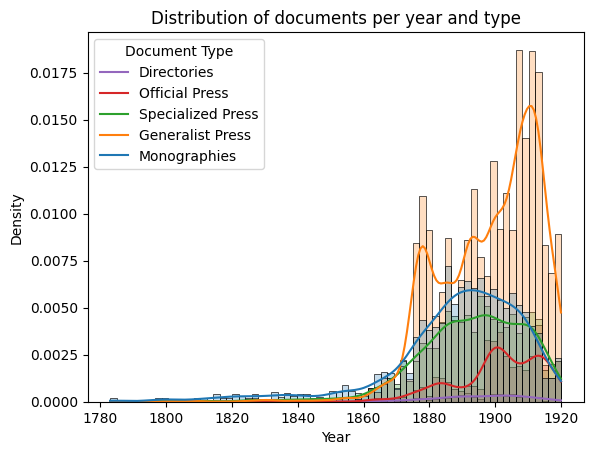

In [7]:
sns.histplot(df, x="date_clean", hue="publication_type", kde=True, bins=70, stat="density", label='Documents', palette=palette_types, alpha=0.25)
plt.title("Distribution of documents per year and type")
plt.xlabel("Year")
plt.legend(title='Document Type', loc='upper left', labels=['Directories', "Official Press", "Specialized Press", "Generalist Press", "Monographies"])
plt.show()

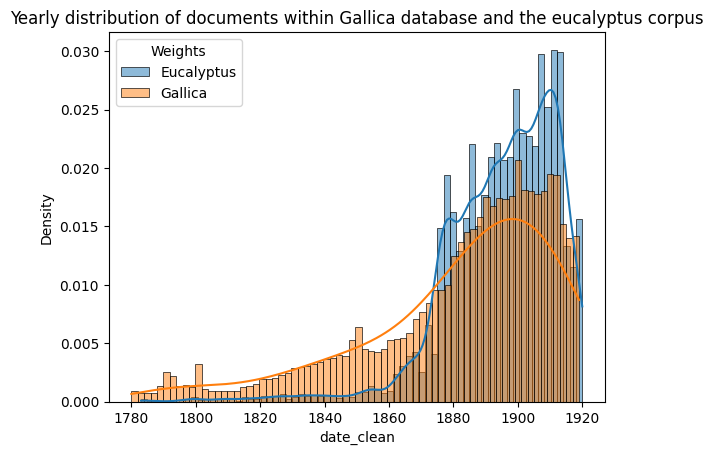

In [8]:
sns.histplot(df, x="date_clean", bins=70, kde=True, stat="density", label="Eucalyptus", alpha=0.5)
sns.histplot(df_gallica_docs, x=df_gallica_docs["year"], weights=df_gallica_docs["docs"], bins=70, kde=True, label="Gallica", stat="density", alpha=0.5)
plt.legend(title= "Weights", loc= "upper left")
plt.title("Yearly distribution of documents within Gallica database and the eucalyptus corpus")
plt.show()

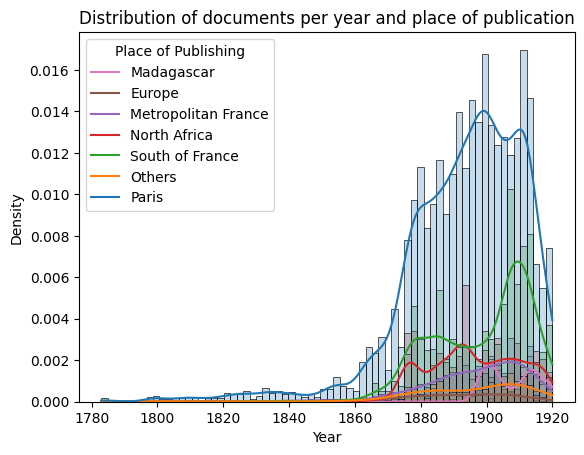

In [10]:
sns.histplot(df, x="date_clean", hue="publisher_country", kde=True, bins=70, stat="density", label='Documents', alpha=0.25)
plt.title("Distribution of documents per year and place of publication")
plt.xlabel("Year")
plt.legend(title='Place of Publishing', loc='upper left', labels=['Madagascar', "Europe", "Metropolitan France", "North Africa", "South of France", "Others", "Paris"])
plt.show()

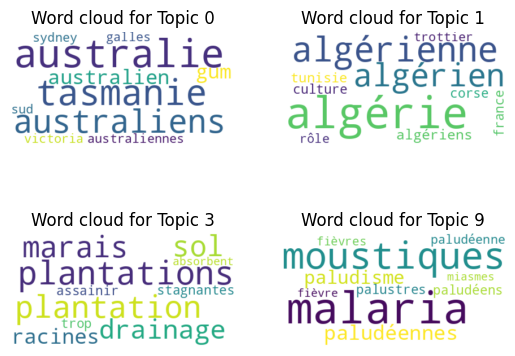

In [11]:
list_of_topics = [0,1,3,9]
fig, ax = plt.subplots(2, 2)
for i, topic in enumerate(list_of_topics):
    text = {word: value for word, value in topic_model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000)
    wc.generate_from_frequencies(text)
    ax[math.floor(i / 2)][i % 2].imshow(wc, interpolation="bilinear")
    ax[math.floor(i / 2)][i % 2].axis("off")
    ax[math.floor(i / 2)][i % 2].set_title(f"Word cloud for Topic {topic}")

plt.show()

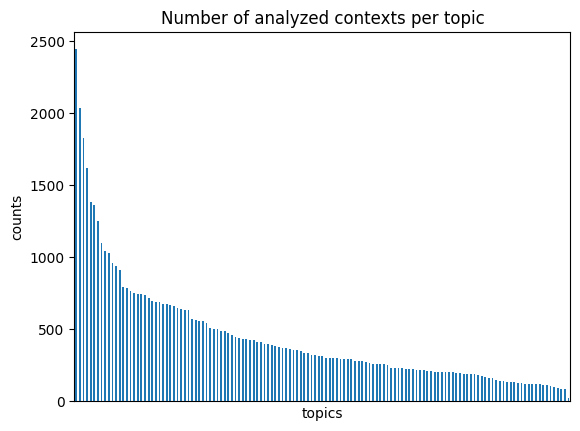

In [ ]:
counts = df_topics_exploded["topics"].value_counts().plot(kind="bar")
plt.xticks([], [])
plt.ylabel("counts")
plt.title("Number of analyzed contexts per topic")
plt.show()

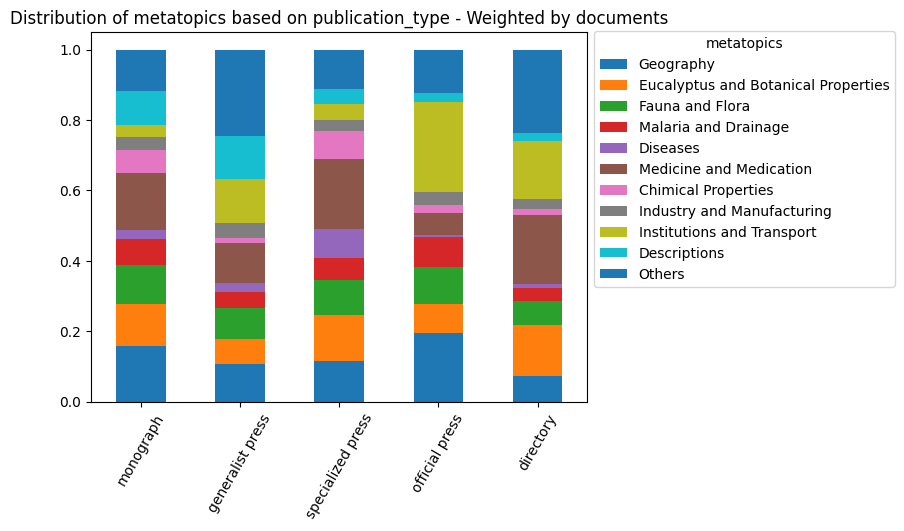

In [13]:
column_order = ['Geography', 'Eucalyptus and Botanical Properties', 'Fauna and Flora', 'Malaria and Drainage', 'Diseases', 'Medicine and Medication', 'Chimical Properties', 'Industry and Manufacturing', 'Institutions and Transport', 'Descriptions', 'Others']
row_order = ["monograph", "generalist press", "specialized press", "official press", "directory"]
plot_histogram(df, "publication_type", "metatopics", columns_to_remove=["Errors"], normalize=True, column_order=column_order, row_order=row_order)

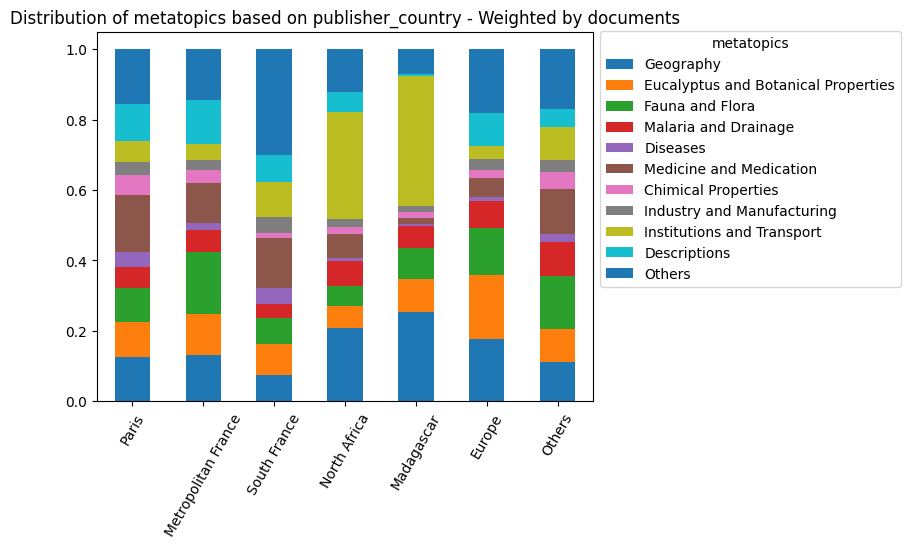

In [14]:
row_order = ["Paris", "Metropolitan France", "South France", "North Africa", "Madagascar", "Europe", "Others"]
plot_histogram(df, "publisher_country", "metatopics", normalize=True, columns_to_remove=["Errors"], column_order=column_order, row_order=row_order)

## 3.2) Lyon between 1900 and 1920

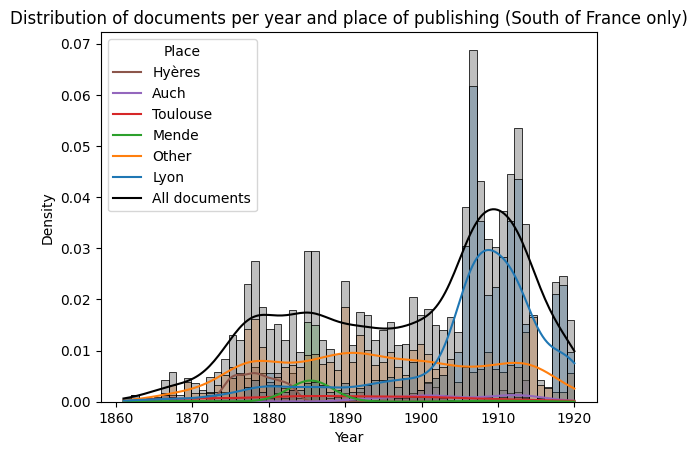

In [15]:
df_south = df[df["publisher_country"] == "South France"]
df_south = df_south[df_south["date_clean"] > 1860]
def place_test(place):
    if place in ["Lyon", "Mende", "Toulouse", "Hyères", "Auch"]:
        return place
    else:
        return "Other"
df_south["place_test"] = df_south["publisher_place_clean"].map(place_test)
bins = int(1920-1860)

sns.histplot(df_south, x="date_clean", hue="place_test", kde=True, bins=bins, stat="density", alpha=0.25)
sns.histplot(df_south, x="date_clean", kde=True, bins=bins, stat="density", color="black", alpha=0.25)

plt.title("Distribution of documents per year and place of publishing (South of France only)")
plt.xlabel("Year")
plt.legend(title='Place', loc='upper left', labels=["Hyères", "Auch", "Toulouse", "Mende", "Other", "Lyon", "All documents"])
plt.show()

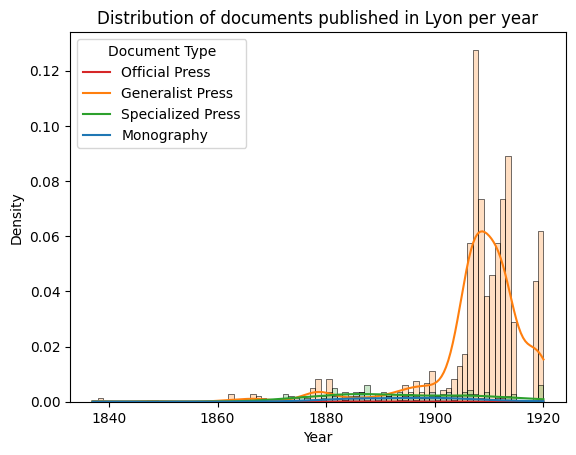

In [16]:
bins = int(df[df["publisher_place_clean"] == "Lyon"]["date_clean"].max() - df[df["publisher_place_clean"] == "Lyon"]["date_clean"].min())

sns.histplot(df[df["publisher_place_clean"] == "Lyon"], x="date_clean", hue="publication_type", kde=True, bins=bins, stat="density", palette=palette_types, alpha=0.25)
plt.title("Distribution of documents published in Lyon per year")
plt.legend(title='Document Type', loc='upper left', labels=["Official Press", "Generalist Press", "Specialized Press", "Monography"])
plt.xlabel("Year")
plt.show()

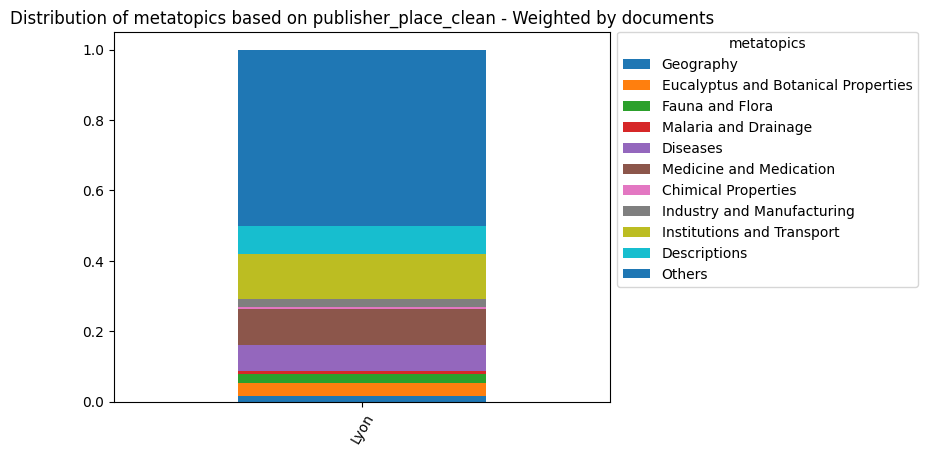

In [17]:
row_order = ["Lyon"]
df_lyon = df[df["publisher_place_clean"] == "Lyon"]
df_lyon = df_lyon[df_lyon["date_clean"] > 1900]
plot_histogram(df_lyon, "publisher_place_clean", "metatopics", normalize=True, columns_to_remove=["Errors"], column_order=column_order, row_order=row_order)

In [18]:
docs_year = [df.loc[df['ark'] == ark, "date_clean"].iloc[0] for ark in docs_ark]
topics_over_time = topic_model.topics_over_time(docs_text, docs_year, nr_bins=60)
topic_model.visualize_topics_over_time(topics_over_time, topics=[46, 88])

## 3.3) Madagascar and the official press

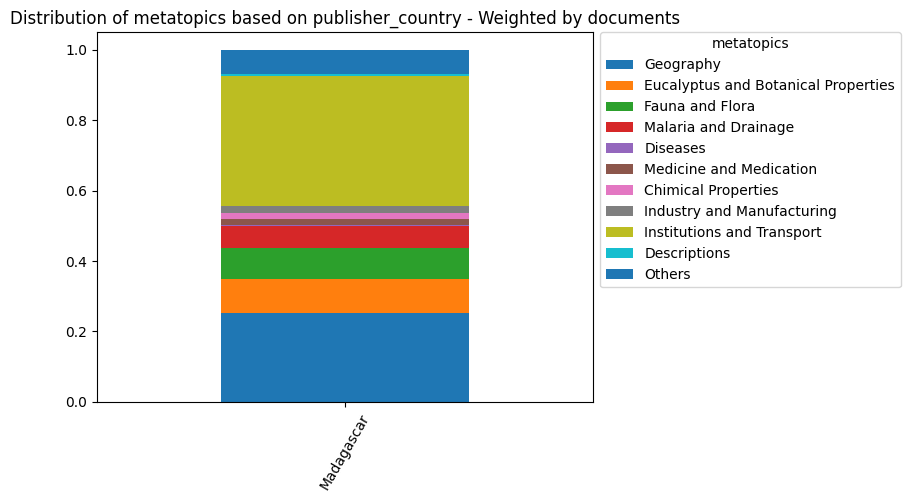

In [19]:
df_madagascar = df[df["publisher_country"] == "Madagascar"]
plot_histogram(df_madagascar, "publisher_country", "metatopics", normalize=True, columns_to_remove=["Errors"], column_order=column_order)

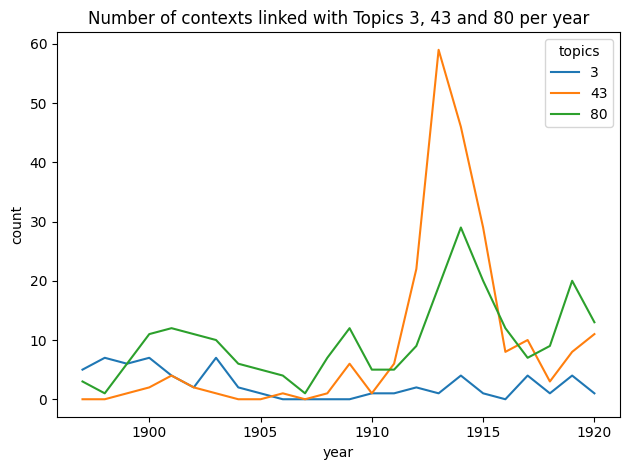

In [20]:
df_madagascar_exploded = df_madagascar.explode("topics")
df_madagascar_exploded = df_madagascar_exploded[df_madagascar_exploded["topics"].isin([3, 43, 80])]
cross_tab_madagascar_exploded = pd.crosstab(df_madagascar_exploded.date_clean, df_madagascar_exploded.topics)
sns.lineplot(cross_tab_madagascar_exploded, dashes=False)
plt.title("Number of contexts linked with Topics 3, 43 and 80 per year")
plt.ylabel("count")
plt.xlabel("year")
plt.tight_layout()
plt.show()

## 3.4) Drainage and the fight against malaria

In [21]:
malaria_topics = [3, 9, 29, 104]

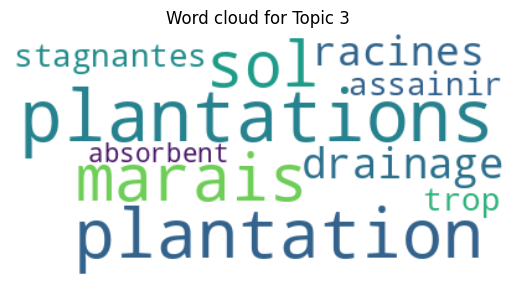

In [24]:
plot_word_cloud(3, topic_model)

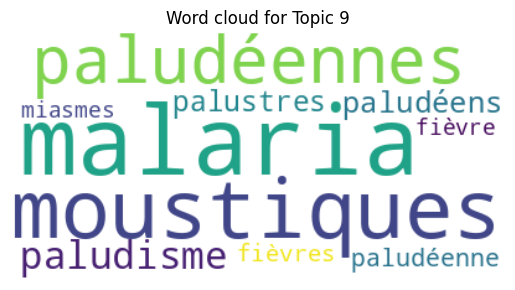

In [35]:
plot_word_cloud(9, topic_model)

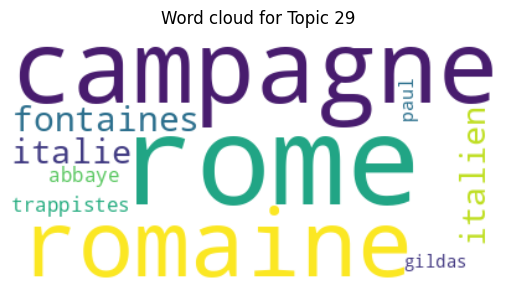

In [36]:
plot_word_cloud(29, topic_model)

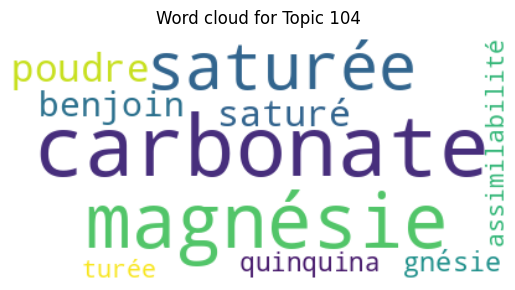

In [37]:
plot_word_cloud(104, topic_model)

In [30]:
# Total of contexts linked with malaria and drainage
print(f"% of contexts: {df_topics_exploded["topics"].value_counts(normalize=True)[malaria_topics].sum() *100}")
df_topics_exploded["topics"].value_counts(normalize=True)

% of contexts: 5.638213267943535


topics
 0      0.040460
 3      0.033766
 1      0.030270
 7      0.026808
 131    0.022914
          ...   
 134    0.001707
 113    0.001541
 117    0.001475
 101    0.001441
-1      0.000447
Name: proportion, Length: 137, dtype: float64

In [34]:
tot_docs_with_malaria = 0
for i, doc in df.iterrows():
    if not set(doc["topics"]).isdisjoint(malaria_topics):
        tot_docs_with_malaria += 1

print(f"% of documents with malaria: {tot_docs_with_malaria / len(df) * 100}")
print(f"Number of documents with 1 occurrence: {df["occurences"].value_counts(normalize=True)[1]}")

% of documents with malaria: 10.965039846431273
Number of documents with 1 occurrence: 0.5658774940375778


In [69]:
total_docs = df.groupby("publisher_country").size()

docs_with_malaria = (
    df[df["metatopics"].apply(lambda x: "Malaria and Drainage" in x)]
    .groupby("publisher_country")
    .size()
)

# Proportion
proportions = (
    docs_with_malaria
    .div(total_docs)
    .fillna(0)
    .rename("proportion")
)

print(proportions)

publisher_country
Europe                 0.152482
Madagascar             0.107547
Metropolitan France    0.098765
North Africa           0.109883
Others                 0.159574
Paris                  0.121387
South France           0.064281
Name: proportion, dtype: float64


In [124]:
topics_malaria_place = {
    3: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    9: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    29: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    104: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
}
df_malaria = df[df['metatopics'].apply(lambda x: "Malaria and Drainage" in x)]
df_malaria["topics"] = df_malaria["topics"].apply(lambda x: [topic for topic in x if topic in topics_malaria_place.keys()])

for i, doc in df_malaria.iterrows():
    for topic in doc["topics"]:
        topics_malaria_place[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publisher_country"] == "Paris":
            topics_malaria_place[topic]["Paris"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Metropolitan France":
            topics_malaria_place[topic]["Metropolitan France"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "South France":
            topics_malaria_place[topic]["South France"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "North Africa":
            topics_malaria_place[topic]["North Africa"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Madagascar":
            topics_malaria_place[topic]["Madagascar"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Europe":
            topics_malaria_place[topic]["Europe"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Others":
            topics_malaria_place[topic]["Others"] += 1 / len(doc["topics"])

topics_malaria_place = pd.DataFrame(topics_malaria_place).T
topics_malaria_place = topics_malaria_place.sort_values(by="all", ascending=False)
topics_malaria_place["all"] = (topics_malaria_place["all"] / topics_malaria_place["all"].sum()) * 100
topics_malaria_place["Paris"] = (topics_malaria_place["Paris"] / topics_malaria_place["Paris"].sum()) * 100
topics_malaria_place["Metropolitan France"] = (topics_malaria_place["Metropolitan France"] / topics_malaria_place["Metropolitan France"].sum()) * 100
topics_malaria_place["South France"] = (topics_malaria_place["South France"] / topics_malaria_place["South France"].sum()) * 100
topics_malaria_place["North Africa"] = (topics_malaria_place["North Africa"] / topics_malaria_place["North Africa"].sum()) * 100
topics_malaria_place["Madagascar"] = (topics_malaria_place["Madagascar"] / topics_malaria_place["Madagascar"].sum()) * 100
topics_malaria_place["Europe"] = (topics_malaria_place["Europe"] / topics_malaria_place["Europe"].sum()) * 100
topics_malaria_place["Others"] = (topics_malaria_place["Others"] / topics_malaria_place["Others"].sum()) * 100

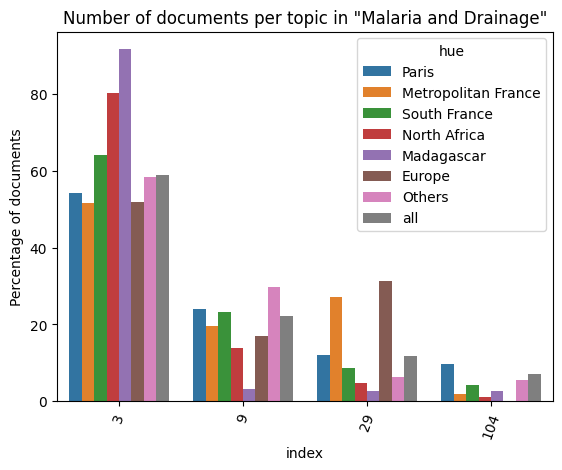

In [120]:
topics_malaria_place_graph = topics_malaria_place.reset_index()
topics_malaria_place_graph = topics_malaria_place_graph.melt(
    id_vars='index',
    value_vars=["Paris", "Metropolitan France", "South France", "North Africa", "Madagascar", "Europe", "Others", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_malaria_place_graph,
    x='index',
    y='value',
    hue='hue',
    order=topics_malaria_place_graph['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Malaria and Drainage"')
plt.xticks(rotation=70)
plt.show()

In [127]:
df_metro_29 = df[df["publisher_country"] == "Metropolitan France"]
df_metro_29 =  df_metro_29[df_metro_29["topics"].apply(lambda x: 29 in x)]
df_metro_29["title_clean"].value_counts()

title_clean
La Semaine religieuse du diocèse de Rouen                                                                                                                   2
Revue de l'Avranchin                                                                                                                                        2
Recueil des publications de la Société havraise d'études diverses                                                                                           2
Culture de l'eucalyptus à St-Paul-Trois-Fontaines (près Rome)                                                                                               2
Journal d'Indre-et-Loire                                                                                                                                    2
Bulletin agricole de l'Ouest                                                                                                                                1
Mémoires de la Société centrale d'agricu

In [128]:
len(df_metro_29)

36

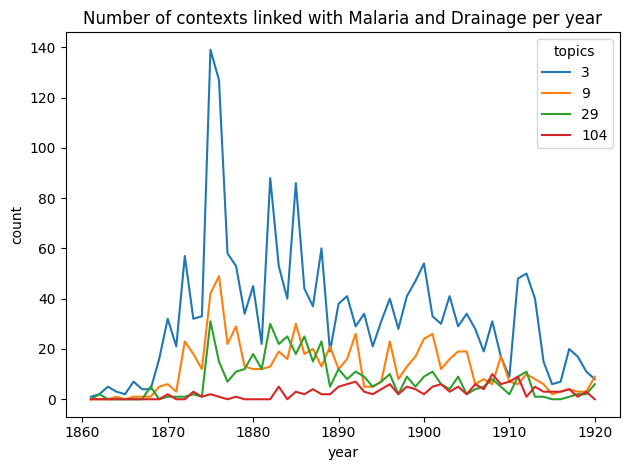

In [90]:
df_malaria_exploded = df_topics_exploded[df_topics_exploded["topics"].isin(malaria_topics)]
df_malaria_exploded = df_malaria_exploded[df_malaria_exploded["date_clean"] > 1860]
cross_tab_malaria_exploded = pd.crosstab(df_malaria_exploded.date_clean, df_malaria_exploded.topics)
sns.lineplot(cross_tab_malaria_exploded, dashes=False)
plt.title("Number of contexts linked with Malaria and Drainage per year")
plt.ylabel("count")
plt.xlabel("year")
plt.tight_layout()
plt.show()

In [ ]:
df_europe = df[df["publisher_country"] == "Europe"]
df_europe[df_europe["topics"].apply(lambda x: 29 in x)].sort_values(by="date_clean")

,ark,title_clean,date_clean,author_name_clean,author_type_clean,author_birth_clean,author_death_clean,publisher_name_clean,publisher_place_clean,publication_type,...,title,author,date,publisher,ocr_quality,topics,metatopics,occurences,occurences_ratio,publisher_country
13351,bd6t542057482,L'Illustration horticole,1876.0,NaN,NaN,NaN,NaN,impr. F. et E. Gyselynck,Gand,generalist press,...,L'Illustration horticole : journal spécial des...,NaN,1876,impr. F. et E. Gyselynck (Gand),89.0,"[29, 99, 7, 14, 92, 131, 110, 0, 131, 14, 4]","[Malaria and Drainage, Eucalyptus and Botanica...",11,0.012212,Europe
15125,bd6t54180116f,L'Illustration horticole,1878.0,NaN,NaN,NaN,NaN,impr. F. et E. Gyselynck,Gand,generalist press,...,L'Illustration horticole : journal spécial des...,NaN,1878-01-01,impr. F. et E. Gyselynck (Gand),89.0,"[29, 69, 37, 99, 32, 0, 2, 8, 2, 4]","[Malaria and Drainage, Others, Eucalyptus and ...",10,0.012026,Europe
16211,bpt6k454235n,Bibliothèque universelle et Revue suisse,1879.0,NaN,NaN,NaN,NaN,Bureau de la Bibliothèque universelle,Genève,specialized press,...,Bibliothèque universelle et Revue suisse,NaN,1879,Bureau de la Bibliothèque universelle (Genève),99.0,[29],[Malaria and Drainage],1,0.000557,Europe
9924,bpt6k106950b,Lettres d'Italie,1880.0,"De Laveleye, Émile",person,1822.0,1892.0,"Librairie européenne C. Muquardt, Merzbach & F...",Bruxelles,monograph,...,Lettres d'Italie : 1878-1879 / par Emile de La...,"De Laveleye, Émile (1822-1892). Auteur du texte",1880,"Librairie européenne C. Muquardt, Merzbach & F...",84.0,"[59, 29, 54, 29, 107, 40, 4]","[Medicine and Medication, Malaria and Drainage...",7,0.008864,Europe
10121,bpt6k65477003,Bulletin de la Société de géographie d'Anvers,1881.0,Koninklijk aardrijkskundig genootschap van Ant...,person,NaN,NaN,Guil. Van Merlen,Anvers,specialized press,...,Bulletin de la Société de géographie d'Anvers,Koninklijk aardrijkskundig genootschap van Ant...,1881,Guil. Van Merlen (Anvers),100.0,"[29, 29, 1, 76, 53, 49, 8, 131, 24, 8, 121, 11...","[Malaria and Drainage, Malaria and Drainage, G...",17,0.010734,Europe
10361,bpt6k5608582h,Trois ans dans l'Afrique australe,1882.0,"Depelchin, Henri",person,1822.0,1900.0,P. Imbreghts,Bruxelles,monograph,...,Trois ans dans l'Afrique australe : débuts de ...,"Depelchin, Henri (1822-1900). Auteur du texte",1882-1883,P. Imbreghts (Bruxelles),97.0,"[29, 47]","[Malaria and Drainage, Others]",2,0.001432,Europe
17121,bd6t541937478,L'Illustration horticole,1883.0,NaN,NaN,NaN,NaN,impr. F. et E. Gyselynck,Gand,generalist press,...,L'Illustration horticole : journal spécial des...,NaN,1883,impr. F. et E. Gyselynck (Gand),88.0,"[14, 14, 29, 3, 20, 131, 7, 7, 4, 75]","[Eucalyptus and Botanical Properties, Eucalypt...",11,0.013516,Europe
10858,bd6t57727877,Les Institutions sanitaires en Italie,1885.0,NaN,NaN,NaN,NaN,U. Hoepli,Milan,monograph,...,Les Institutions sanitaires en Italie,NaN,1885,U. Hoepli (Milan),87.0,"[9, 20, 48, 48, 99, 48, 9, 8, 29, 8, 48]","[Malaria and Drainage, Fauna and Flora, Medici...",11,0.004026,Europe
10977,bd6t54180134c,L'Illustration horticole,1886.0,NaN,NaN,NaN,NaN,impr. F. et E. Gyselynck,Gand,generalist press,...,L'Illustration horticole : journal spécial des...,NaN,1886-01-25,impr. F. et E. Gyselynck (Gand),89.0,"[49, 0, 24, 8, 29, 2, 0, 0, 0, 4]","[Eucalyptus and Botanical Properties, Geograph...",11,0.013901,Europe
525,bpt6k9788945w,Congrès périodique international des sciences ...,1886.0,"Lange, Carl Georg",person,1834.0,1900.0,F. Hegel,Copenhague,monograph,...,Congrès périodique international des sciences ...,"Lange, Carl Georg (1834-1900). Auteur du texte",1886,F. Hegel (Copenhague),100.0,"[9, 28, 9, 29, 28, 3, 42, 9, 9]","[Malaria and Drainage, Others, Malaria and Dra...",10,0.004482,Europe


: 

# 4) Discussion

In [6]:
df[df["publication_type"] == "monograph"]["publisher_country"].value_counts(normalize=True)

publisher_country
Paris                  0.789339
South France           0.064013
Metropolitan France    0.059125
Others                 0.040503
Europe                 0.024674
North Africa           0.022114
Madagascar             0.000233
Name: proportion, dtype: float64

In [7]:
df["publisher_country"].value_counts(normalize=True)

publisher_country
Paris                  0.575534
South France           0.183701
North Africa           0.094759
Metropolitan France    0.065965
Others                 0.032808
Madagascar             0.030830
Europe                 0.016404
Name: proportion, dtype: float64